rows with missing data:  569
header: 
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  t

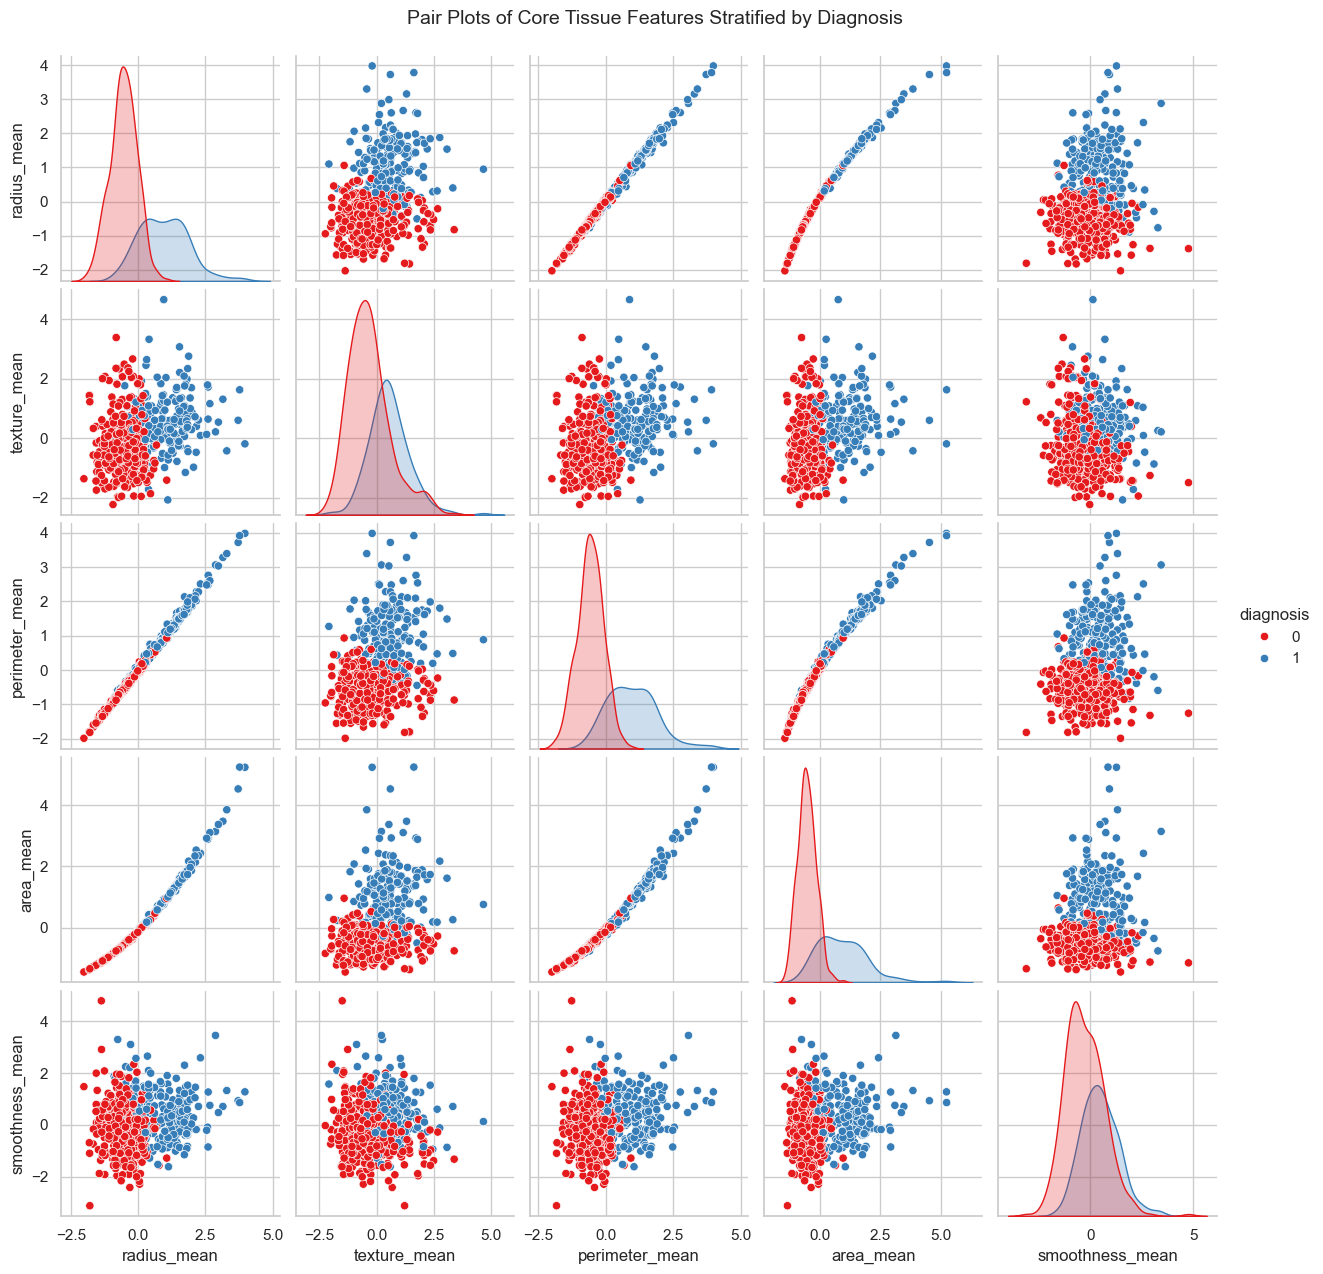

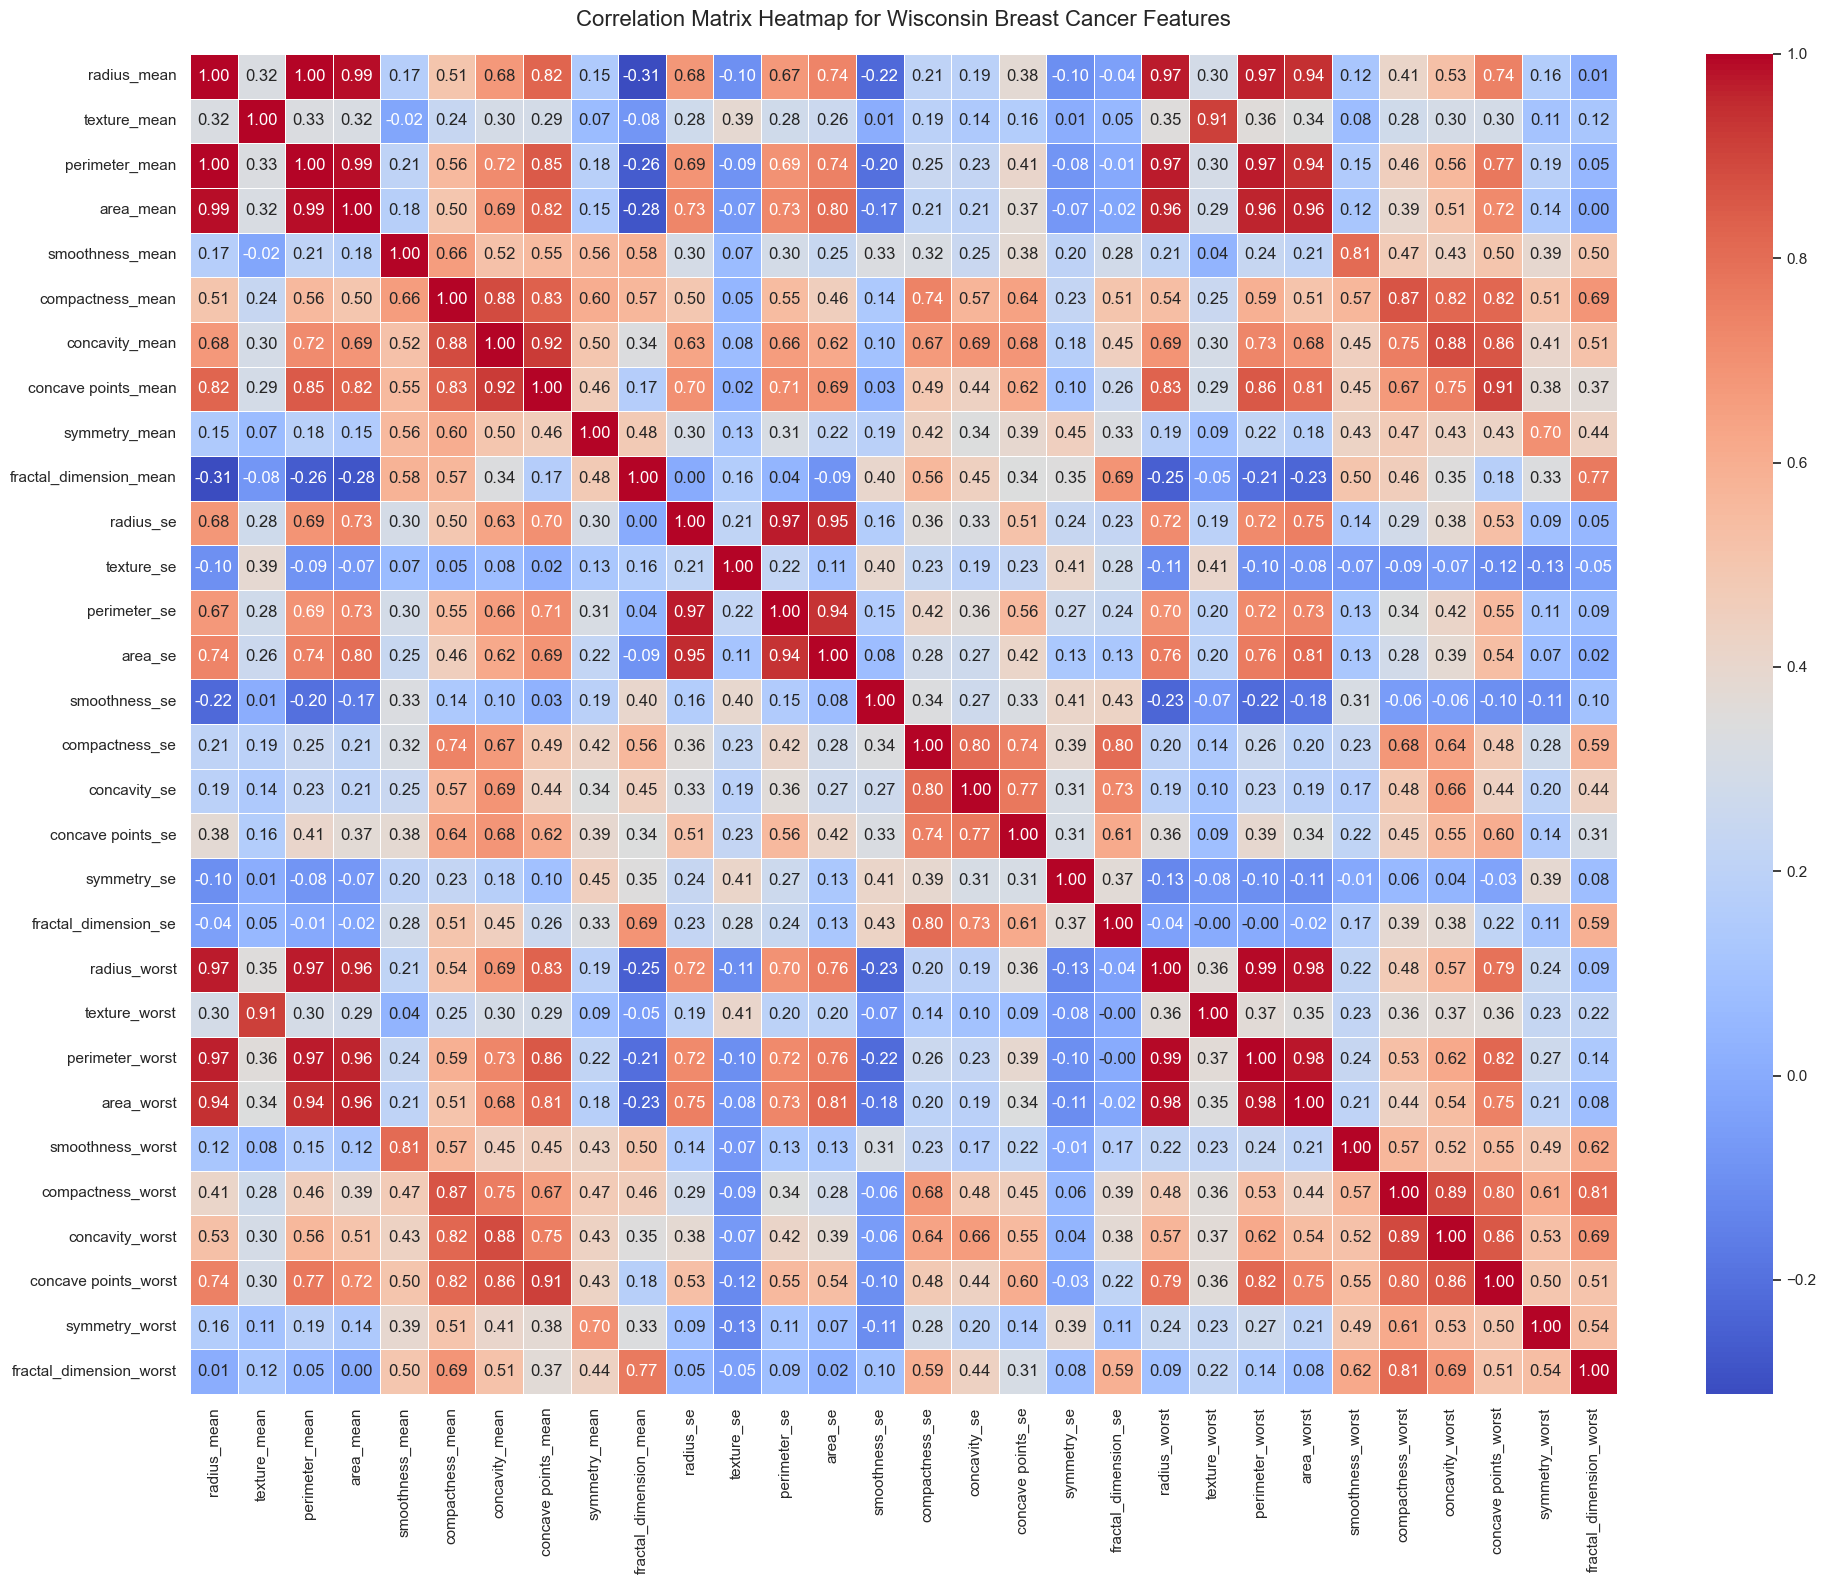

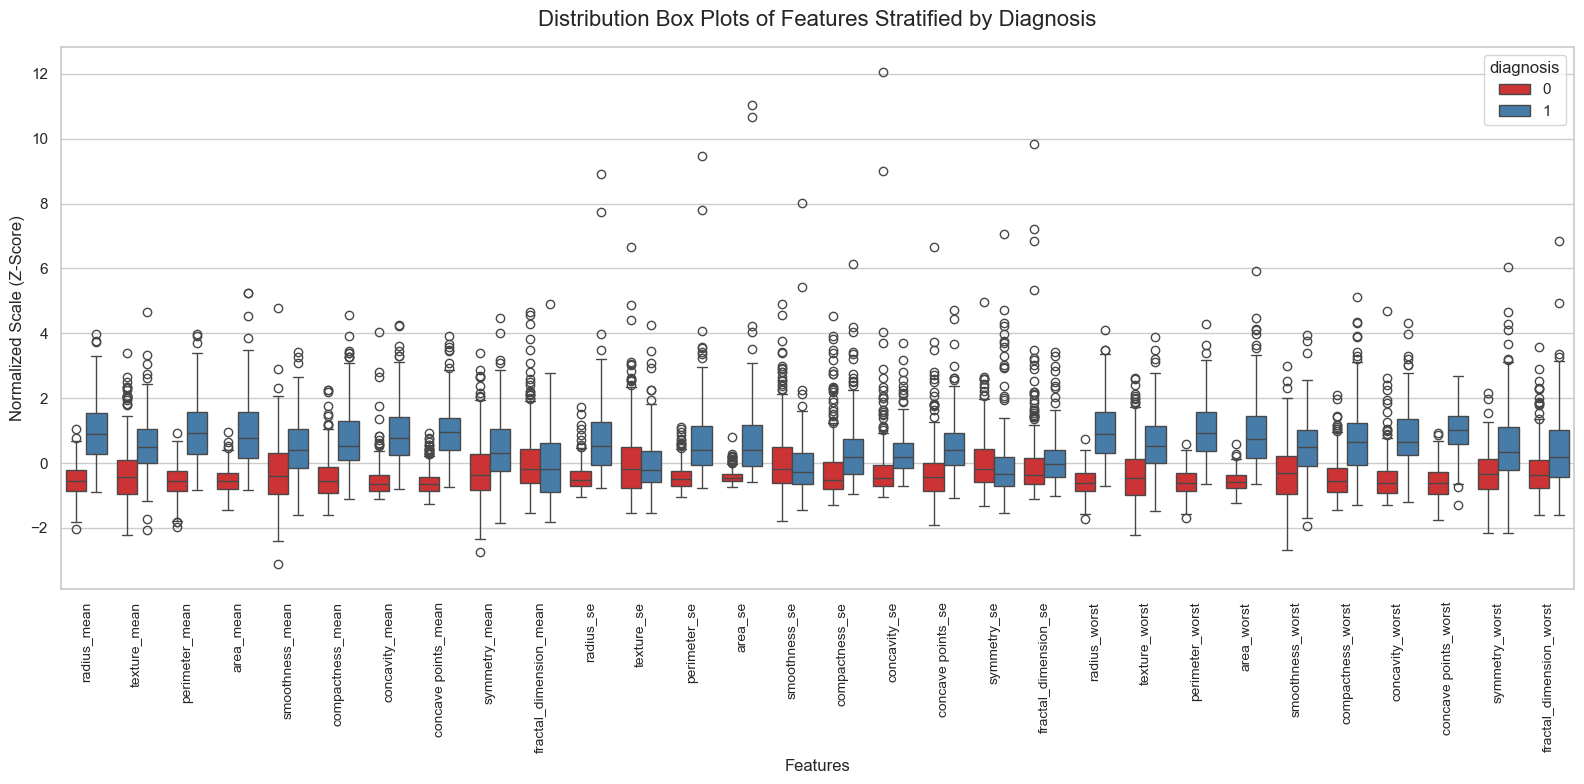

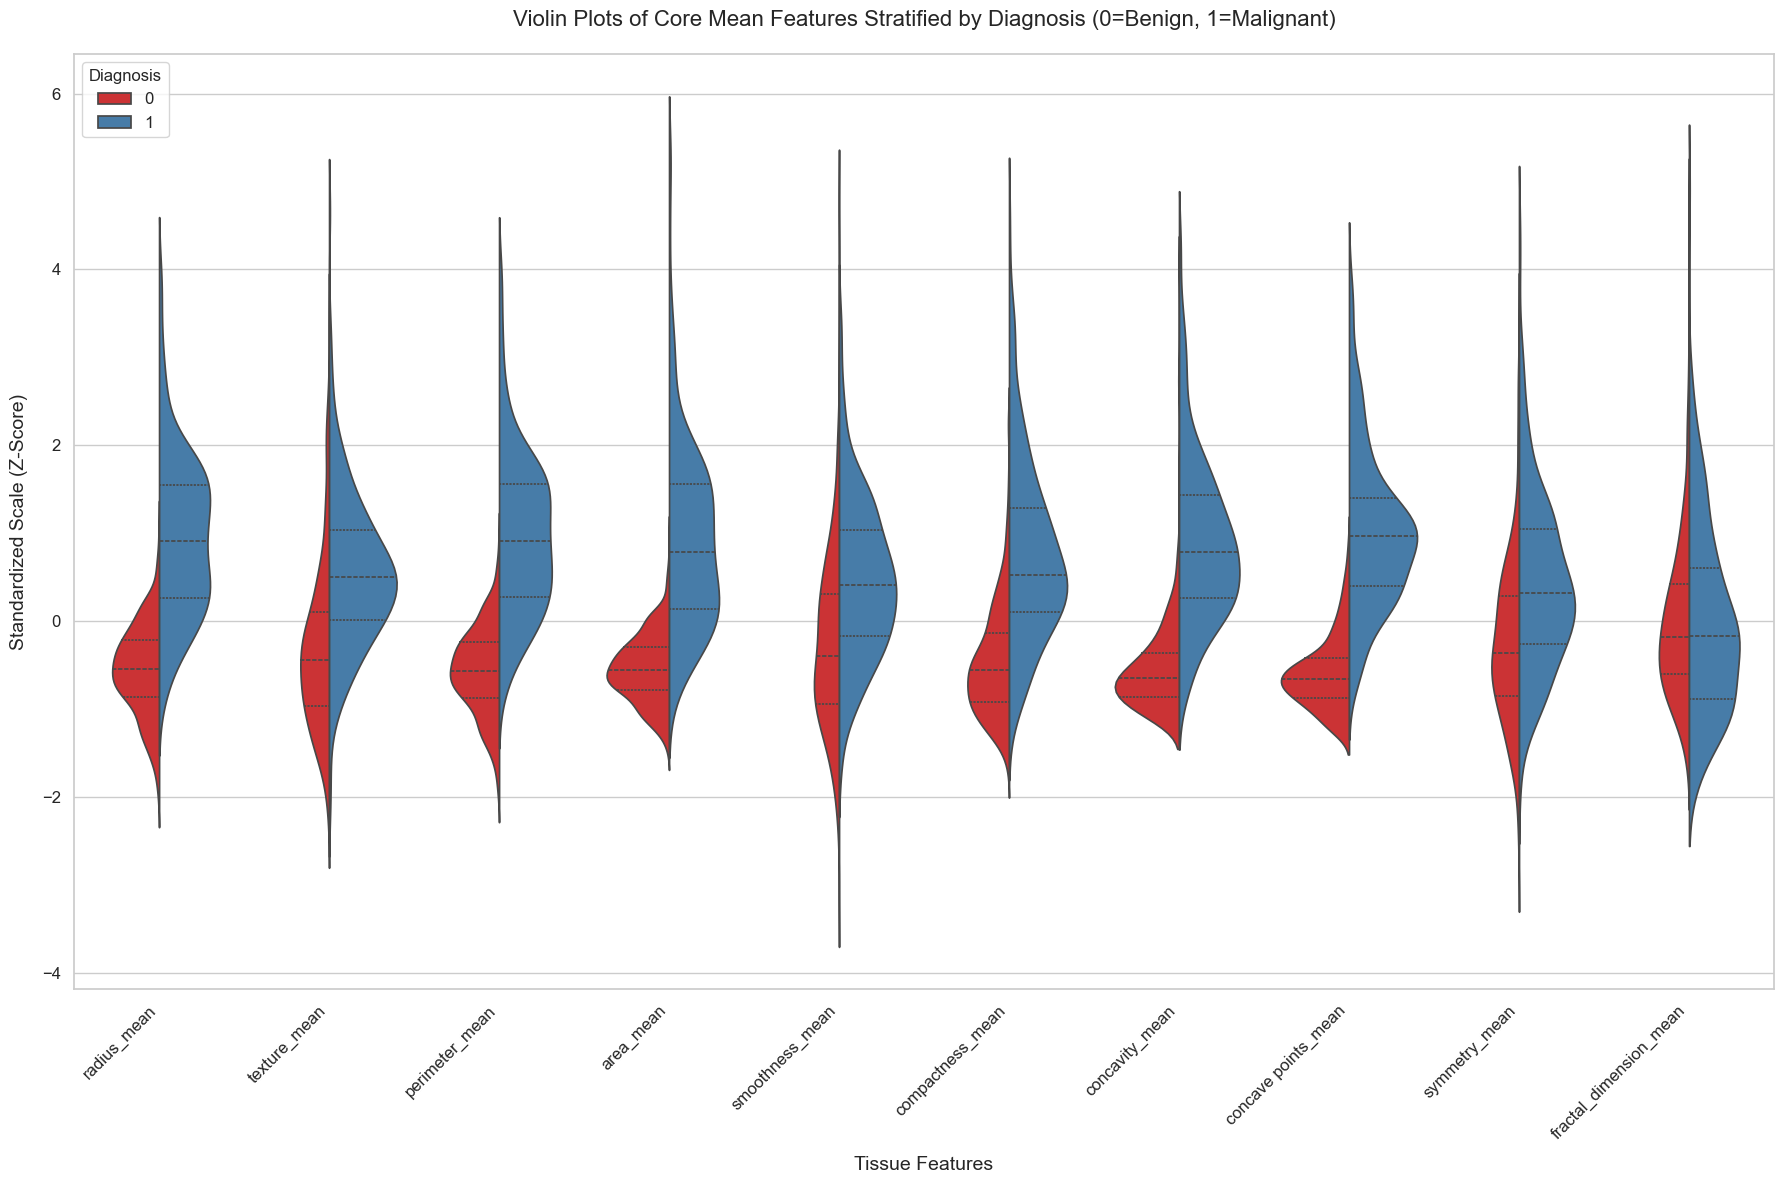

In [1]:
#---BREAST CANCER---

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#--- STEP 2

df = pd.read_csv('Breast Cancer.csv')

total_rows_with_missing = df.isnull().any(axis=1).sum()
print ('rows with missing data: ', total_rows_with_missing)

df = df.drop('Unnamed: 32', axis=1)

print( 'header: \n', df.head(5))

#---STEP 3--- Eliminate columns. 

df = df.iloc[:, 1:]

#---STEP 4---

from sklearn.preprocessing import StandardScaler, LabelEncoder

# Encoding categorical labels (diagnosis: M/B -> 1/0)
if 'diagnosis' in df.columns:
    le = LabelEncoder()
    df['diagnosis'] = le.fit_transform(df['diagnosis']) 
    # Mapped: M (Malignant) = 1, B (Benign) = 0 (or vice versa depending on fit)

# Scaling and Normalization (StandardScaler for continuous feature columns)
feature_cols = [col for col in df.columns if col != 'diagnosis']
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# Export refined output to CSV
df.to_csv("data_refined.csv", index=False)
print("Preprocessing complete. Saved to data_refined.csv")



#---STEP 5---


df = pd.read_csv("data_refined.csv")

# Identify the target and feature columns
target_col = 'diagnosis'  # 1 for Malignant, 0 for Benign
feature_cols = [col for col in df.columns if col != target_col]

# Set a clean visual style for all plots
sns.set_theme(style="whitegrid")


# VISUALIZATION 1: Pair Plots (Core Features)

# We select the main structural measurements to keep the visualization clear and readable
core_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']
# Fallback to the first 5 columns if the exact names above differ in your file structure
core_features = [f for f in core_features if f in df.columns] or feature_cols[:5]


# hue="diagnosis" splits the data points by class (e.g., Malignant vs Benign)
pair_plot = sns.pairplot(df, vars=core_features, hue=target_col, palette="Set1", diag_kind="kde")
pair_plot.fig.suptitle("Pair Plots of Core Tissue Features Stratified by Diagnosis", y=1.02, fontsize=14)
plt.show()


# VISUALIZATION 2: Correlation Matrix Heatmap


plt.figure(figsize=(20, 16))

# Compute Pearson correlation coefficients across all 30 features
corr_matrix = df[feature_cols].corr()

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, cbar=True)
plt.title("Correlation Matrix Heatmap for Wisconsin Breast Cancer Features", fontsize=16, pad=20)
plt.tight_layout()
plt.show()


# VISUALIZATION 3: Feature Box Plots


plt.figure(figsize=(16, 8))

# "Melt" the dataframe from wide to long format so seaborn can plot all features along the X-axis
df_melted = pd.melt(df, id_vars=[target_col], value_vars=feature_cols, var_name='Feature', value_name='Value')

# Draw side-by-side boxplots for each feature, split by diagnosis
sns.boxplot(x='Feature', y='Value', hue=target_col, data=df_melted, palette="Set1")
plt.xticks(rotation=90, fontsize=10)
plt.title("Distribution Box Plots of Features Stratified by Diagnosis", fontsize=16, pad=15)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Normalized Scale (Z-Score)", fontsize=12)
plt.tight_layout()
plt.show()


# ---STEP 6---

target_col = 'diagnosis'  # 1 for Malignant, 0 for Benign

# Isolate the 'mean' feature columns for clear layout visibility
mean_features = [col for col in df.columns if col.endswith('_mean')]

# Set up the plotting grid
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 12))

# Melt the dataframe into a long format suitable for Seaborn
df_melted = pd.melt(df, id_vars=[target_col], value_vars=mean_features, 
                    var_name='Feature', value_name='Normalized Value')

# Create the violin plot
# split=True merges the Benign and Malignant distributions into a single violin per feature
sns.violinplot(x='Feature', y='Normalized Value', hue=target_col, 
               data=df_melted, split=True, inner='quart', palette='Set1')

# Polish the visual layout
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title("Violin Plots of Core Mean Features Stratified by Diagnosis (0=Benign, 1=Malignant)", fontsize=16, pad=20)
plt.xlabel("Tissue Features", fontsize=14, labelpad=10)
plt.ylabel("Standardized Scale (Z-Score)", fontsize=14, labelpad=10)
plt.legend(title="Diagnosis", fontsize=12, title_fontsize=12)
plt.tight_layout()

# Display the plot
plt.show()


